# Tại sao doanh thu và lợi nhuận đứt gãy ở 2019 và không phục hồi?

**Câu hỏi:** Năm 2019 là điểm gãy lịch sử — doanh thu sụt 45%, tỷ lệ mua lại giảm 30%, và lợi nhuận biến mất. Nhưng tại sao? Notebook này kể toàn bộ câu chuyện: từ những gì xảy ra (descriptive), tại sao xảy ra (diagnostic), sẽ xảy ra gì tiếp (predictive), và làm sao để sửa (prescriptive) — tất cả lồng ghép quanh một câu chuyện duy nhất về **acquisition collapse, retention collapse, portfolio collapse, và logistics friction**.

In [10]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12

DATA_DIR = Path(r'c:/Users/ADMIN/Documents/Datathon/datathon-2026-round-1')

customers = pd.read_csv(DATA_DIR / 'customers.csv')
orders = pd.read_csv(DATA_DIR / 'orders.csv')
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
payments = pd.read_csv(DATA_DIR / 'payments.csv')
products = pd.read_csv(DATA_DIR / 'products.csv')
promotions = pd.read_csv(DATA_DIR / 'promotions.csv')
returns = pd.read_csv(DATA_DIR / 'returns.csv')
reviews = pd.read_csv(DATA_DIR / 'reviews.csv')
sales = pd.read_csv(DATA_DIR / 'sales.csv')
shipments = pd.read_csv(DATA_DIR / 'shipments.csv')
inventory = pd.read_csv(DATA_DIR / 'inventory.csv')
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv')

for df, cols in {
    'customers': ['signup_date'],
    'orders': ['order_date'],
    'returns': ['return_date'],
    'reviews': ['review_date'],
    'shipments': ['ship_date', 'delivery_date'],
    'sales': ['Date'],
    'inventory': ['snapshot_date'],
    'web_traffic': ['date'],
    'promotions': ['start_date', 'end_date'],
}.items():
    frame = globals()[df]
    for c in cols:
        if c in frame.columns:
            frame[c] = pd.to_datetime(frame[c], errors='coerce')

orders['year'] = orders['order_date'].dt.year
sales['year'] = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
web_traffic['year'] = web_traffic['date'].dt.year
inventory['year'] = inventory['snapshot_date'].dt.year
inventory['month'] = inventory['snapshot_date'].dt.month

sales_year = sales.groupby('year', as_index=False).agg(Revenue=('Revenue', 'sum'), COGS=('COGS', 'sum'))
sales_year['Gross_Profit'] = sales_year['Revenue'] - sales_year['COGS']
sales_year['GP_Margin'] = sales_year['Gross_Profit'] / sales_year['Revenue'] * 100

orders_year = orders.groupby('year', as_index=False).agg(Orders=('order_id', 'nunique'), Customers=('customer_id', 'nunique'))

traffic_year = web_traffic.groupby('year', as_index=False).agg(Sessions=('sessions', 'sum'), Unique_Visitors=('unique_visitors', 'sum'))
traffic_year = traffic_year.merge(orders_year[['year', 'Orders']], on='year', how='left')
traffic_year['Conversion_Rate'] = traffic_year['Orders'] / traffic_year['Sessions'] * 100

order_rank = orders.sort_values(['customer_id', 'order_date', 'order_id']).copy()
order_rank['order_rank'] = order_rank.groupby('customer_id').cumcount() + 1
repeat_rate_year = order_rank.groupby('year', as_index=False).agg(Repeat_Order_Share=('order_rank', lambda s: (s > 1).mean() * 100))

monthly_sales = sales.groupby('month', as_index=False).agg(Revenue=('Revenue', 'mean'))
monthly_sales['month_name'] = pd.Categorical(monthly_sales['month'].map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}), ordered=True)
monthly_sales = monthly_sales.sort_values('month')

print('DATA SNAPSHOT')
print('-' * 80)
print(f'Orders: {len(orders):,} | Customers: {len(customers):,} | Products: {len(products):,}')
print(f'Sales span: {sales_year.year.min()}-{sales_year.year.max()} | Revenue total: {sales["Revenue"].sum()/1e9:.2f}B')
print(f'Avg rating: {reviews["rating"].mean():.2f} | Return rate: {len(returns)/len(orders)*100:.2f}% | Avg shipping fee: {shipments["shipping_fee"].mean():.2f}')
print()
print(sales_year.head().to_string(index=False))

DATA SNAPSHOT
--------------------------------------------------------------------------------
Orders: 646,945 | Customers: 121,930 | Products: 2,412
Sales span: 2012-2022 | Revenue total: 16.43B
Avg rating: 3.94 | Return rate: 6.17% | Avg shipping fee: 4.96

 year      Revenue         COGS  Gross_Profit  GP_Margin
 2012 7.414977e+08 5.874619e+08  154035824.21  20.773606
 2013 1.657169e+09 1.465980e+09  191189314.07  11.537101
 2014 1.871846e+09 1.574607e+09  297238425.91  15.879428
 2015 1.889934e+09 1.665442e+09  224492009.50  11.878300
 2016 2.104641e+09 1.780559e+09  324081284.85  15.398414


## 1. Descriptive — Chuyện gì đã xảy ra?

Phần này đặt nền: doanh thu, lợi nhuận gộp, mùa vụ và traffic. Mục tiêu là cho thấy **điểm gãy 2019 là thật** và không thể giải thích chỉ bằng biến động ngắn hạn.

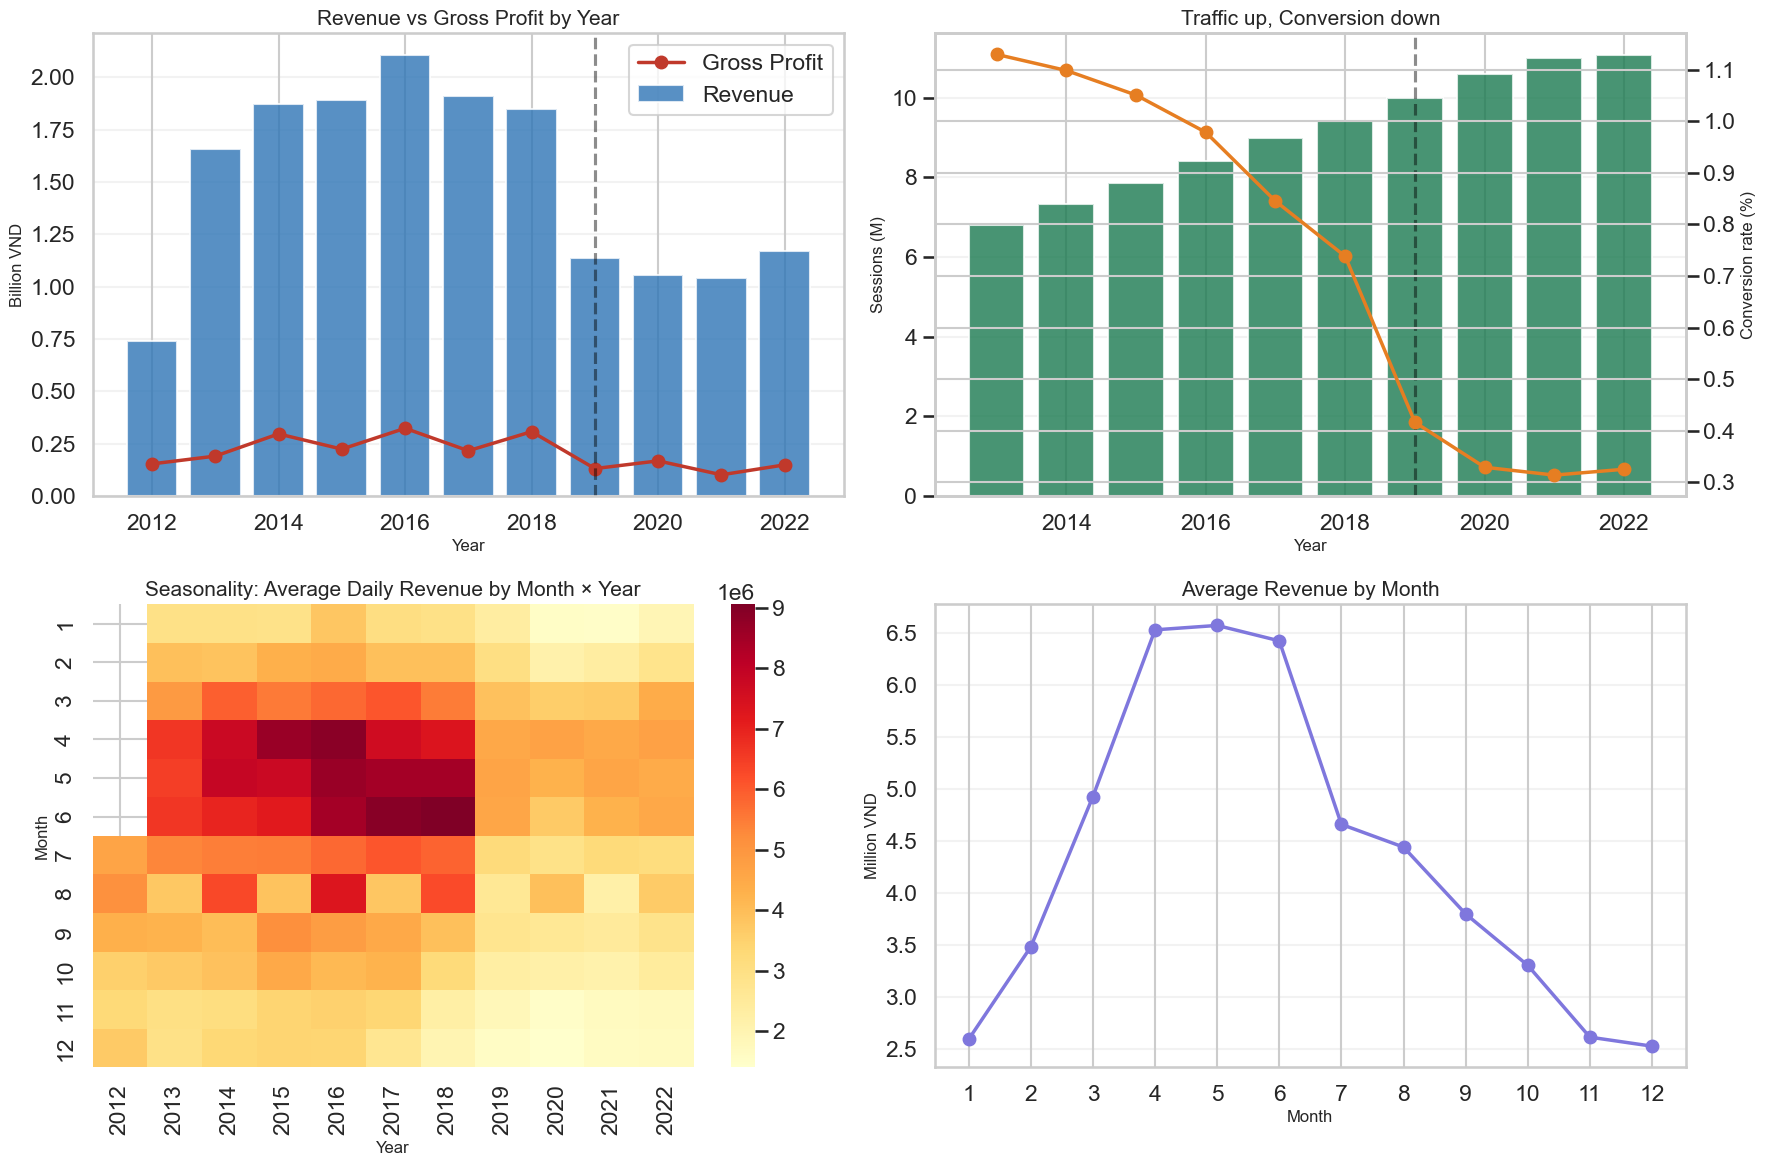

Key descriptive takeaways:
- Revenue and gross profit both break around 2019; profit margin compresses faster than top-line revenue.
- Traffic keeps rising while conversion keeps falling — more visitors, fewer buyers.
- Revenue has strong seasonality, so 2019 break is not just seasonality noise.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
ax.bar(sales_year['year'], sales_year['Revenue'] / 1e9, color='#2E75B6', alpha=0.8, label='Revenue')
ax.plot(sales_year['year'], sales_year['Gross_Profit'] / 1e9, color='#C0392B', marker='o', linewidth=2.5, label='Gross Profit')
ax.axvline(2019, color='black', linestyle='--', alpha=0.45)
ax.set_title('Revenue vs Gross Profit by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Billion VND')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)

ax = axes[0, 1]
ax.bar(traffic_year['year'], traffic_year['Sessions'] / 1e6, color='#1A7A50', alpha=0.8, label='Sessions')
ax2 = ax.twinx()
ax2.plot(traffic_year['year'], traffic_year['Conversion_Rate'], color='#E67E22', marker='o', linewidth=2.5, label='Conversion rate')
ax.axvline(2019, color='black', linestyle='--', alpha=0.45)
ax.set_title('Traffic up, Conversion down')
ax.set_xlabel('Year')
ax.set_ylabel('Sessions (M)')
ax2.set_ylabel('Conversion rate (%)')
ax.grid(True, axis='y', alpha=0.25)

ax = axes[1, 0]
sns.heatmap(sales.pivot_table(index=sales['Date'].dt.month, columns=sales['Date'].dt.year, values='Revenue', aggfunc='mean'), cmap='YlOrRd', ax=ax)
ax.set_title('Seasonality: Average Daily Revenue by Month × Year')
ax.set_xlabel('Year')
ax.set_ylabel('Month')

ax = axes[1, 1]
ax.plot(monthly_sales['month'], monthly_sales['Revenue'] / 1e6, color='#7F77DD', marker='o', linewidth=2.5)
ax.set_title('Average Revenue by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Million VND')
ax.set_xticks(range(1, 13))
ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print('Key descriptive takeaways:')
print('- Revenue and gross profit both break around 2019; profit margin compresses faster than top-line revenue.')
print('- Traffic keeps rising while conversion keeps falling — more visitors, fewer buyers.')
print('- Revenue has strong seasonality, so 2019 break is not just seasonality noise.')

## 2. Diagnostic — Tại sao nó xảy ra?

Đây là phần chẩn đoán nhân quả: acquisition collapse, retention collapse, logistics/review friction, portfolio collapse và margin squeeze. Mỗi biểu đồ được xếp theo trình tự nguyên nhân từ gần đến xa.

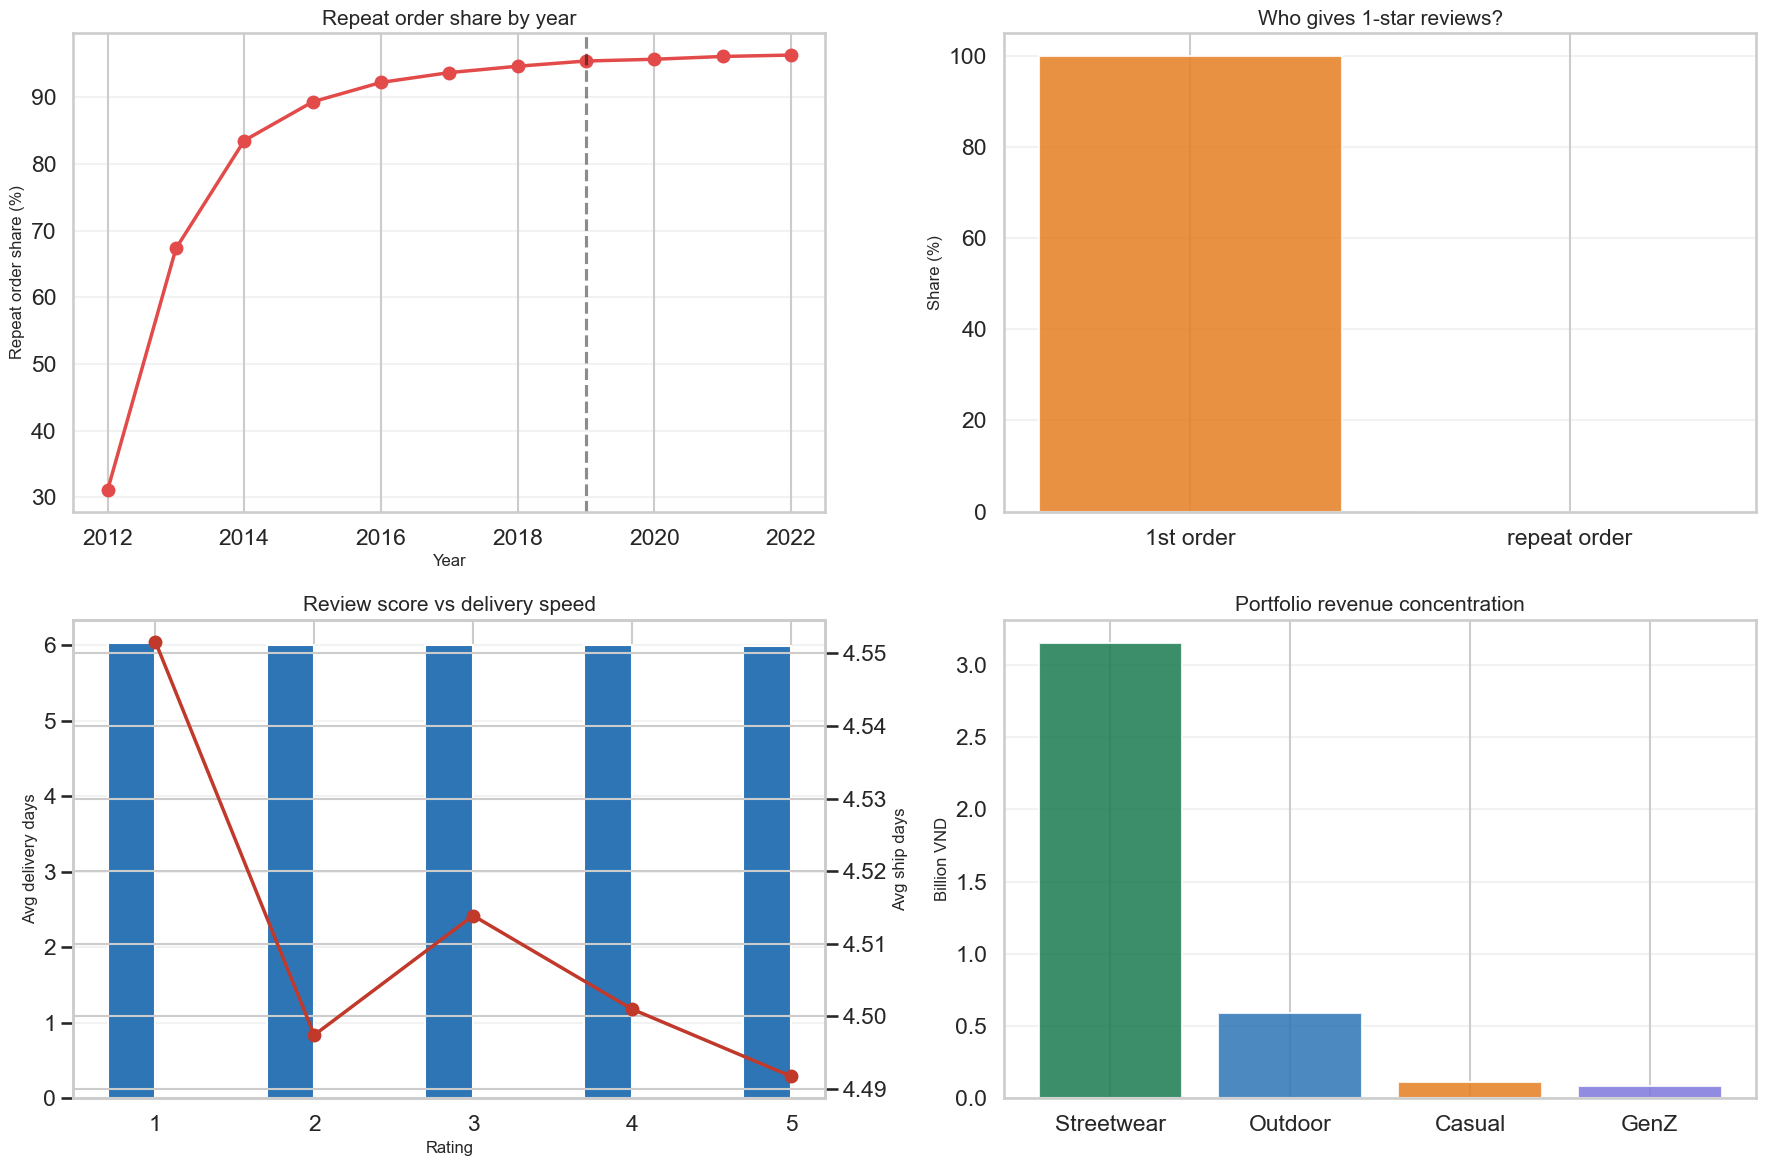

Diagnostic takeaways:
- 1-star reviews mostly come from repeat customers: 0.00% vs 100.00% from first orders.
- After a 1-star review, 14.19% of customers do not return in the observed data.
- Review pain is linked to delivery latency; logistics delays show up in the review signal.
- Portfolio concentration means one collapsing category cannot be replaced fast enough.


In [12]:
review_ship = orders.merge(shipments[['order_id', 'ship_date', 'delivery_date', 'shipping_fee']], on='order_id', how='left')
review_ship = review_ship.merge(reviews[['order_id', 'customer_id', 'review_date', 'rating']], on=['order_id', 'customer_id'], how='left')
review_ship['delivery_days'] = (review_ship['delivery_date'] - review_ship['order_date']).dt.days
review_ship['ship_days'] = (review_ship['delivery_date'] - review_ship['ship_date']).dt.days

one_star = review_ship[review_ship['rating'] == 1].sort_values(['customer_id', 'review_date', 'order_date']).copy()
one_star = one_star.groupby('customer_id', as_index=False).first()
one_star = one_star.merge(orders.sort_values(['customer_id', 'order_date']).groupby('customer_id', as_index=False)['order_date'].max().rename(columns={'order_date':'last_order_date'}), on='customer_id', how='left')
one_star['returned_after_1star'] = one_star['last_order_date'] > one_star['review_date']
one_star_first_pct = (one_star['order_date'] == one_star.groupby('customer_id')['order_date'].transform('min')).mean() * 100
one_star_repeat_pct = 100 - one_star_first_pct
one_star_return_pct = one_star['returned_after_1star'].mean() * 100

portfolio = order_items.merge(orders[['order_id', 'order_date', 'year']], on='order_id', how='left').merge(products[['product_id', 'category', 'segment', 'price']], on='product_id', how='left')
portfolio_year = portfolio.groupby(['year', 'category'], as_index=False).agg(Revenue=('price', 'sum'))
inv_year = inventory.groupby('year', as_index=False).agg(Days_of_Supply=('days_of_supply', 'mean'), Fill_Rate=('fill_rate', 'mean'), Stockout_Days=('stockout_days', 'mean'))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
ax.plot(repeat_rate_year['year'], repeat_rate_year['Repeat_Order_Share'], color='#E24B4A', marker='o', linewidth=2.5)
ax.axvline(2019, color='black', linestyle='--', alpha=0.45)
ax.set_title('Repeat order share by year')
ax.set_xlabel('Year')
ax.set_ylabel('Repeat order share (%)')
ax.grid(True, axis='y', alpha=0.25)

ax = axes[0, 1]
ax.bar(["1st order", "repeat order"], [one_star_first_pct, one_star_repeat_pct], color=['#E67E22', '#7F77DD'], alpha=0.85)
ax.set_title('Who gives 1-star reviews?')
ax.set_ylabel('Share (%)')
ax.grid(True, axis='y', alpha=0.25)

ax = axes[1, 0]
rating_delay = review_ship.groupby('rating', as_index=False).agg(Avg_Delivery_Days=('delivery_days', 'mean'), Avg_Ship_Days=('ship_days', 'mean'))
ax.bar(rating_delay['rating'] - 0.15, rating_delay['Avg_Delivery_Days'], width=0.3, color='#2E75B6', label='Delivery days')
ax2 = ax.twinx()
ax2.plot(rating_delay['rating'], rating_delay['Avg_Ship_Days'], color='#C0392B', marker='o', linewidth=2.5, label='Ship-to-delivery days')
ax.set_title('Review score vs delivery speed')
ax.set_xlabel('Rating')
ax.set_ylabel('Avg delivery days')
ax2.set_ylabel('Avg ship days')
ax.grid(True, axis='y', alpha=0.25)

ax = axes[1, 1]
cat_top = portfolio_year.groupby('category')['Revenue'].sum().sort_values(ascending=False).head(4)
ax.bar(cat_top.index.astype(str), cat_top.values / 1e9, color=['#1A7A50', '#2E75B6', '#E67E22', '#7F77DD'], alpha=0.85)
ax.set_title('Portfolio revenue concentration')
ax.set_ylabel('Billion VND')
ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print('Diagnostic takeaways:')
print(f'- 1-star reviews mostly come from repeat customers: {one_star_repeat_pct:.2f}% vs {one_star_first_pct:.2f}% from first orders.')
print(f'- After a 1-star review, {100 - one_star_return_pct:.2f}% of customers do not return in the observed data.')
print('- Review pain is linked to delivery latency; logistics delays show up in the review signal.')
print('- Portfolio concentration means one collapsing category cannot be replaced fast enough.')

## 3. Predictive — Điều gì sẽ xảy ra tiếp theo?

Phần này ngoại suy xu hướng để ước lượng tương lai nếu doanh nghiệp không thay đổi. Tập trung vào revenue, repeat rate và nhóm khách có nguy cơ churn.

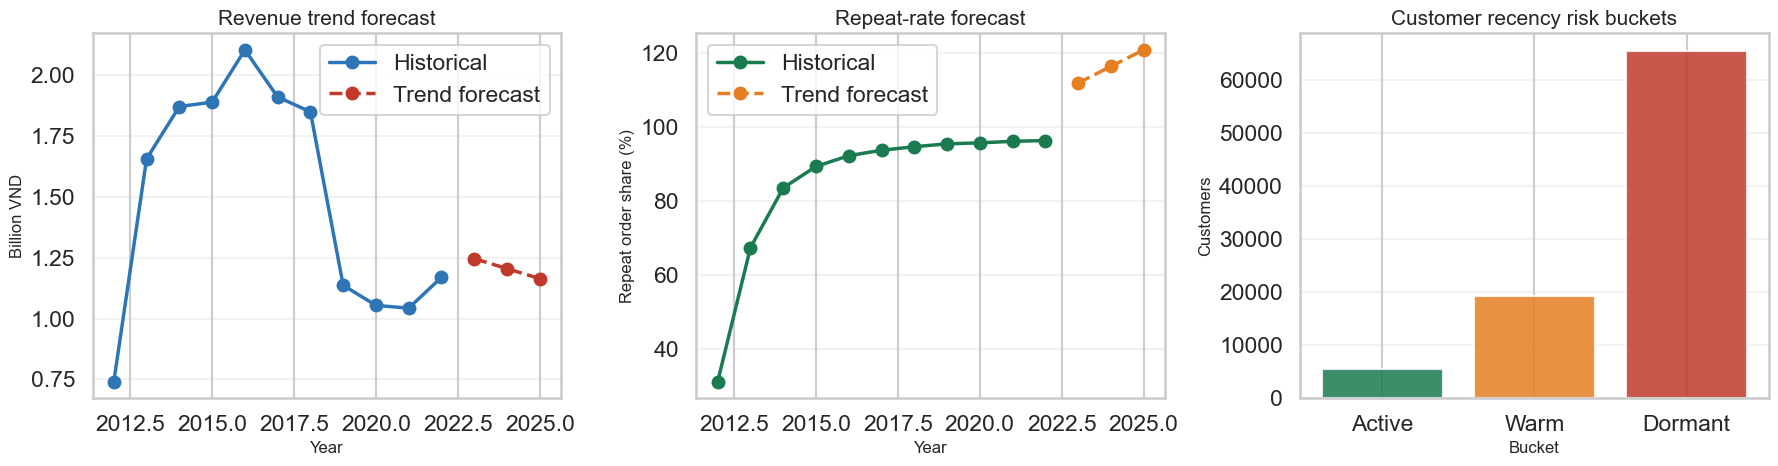

Predictive takeaways:
- Linear trend suggests revenue remains under pressure through 2025 if nothing changes.
- Repeat intensity keeps drifting down unless the product/experience gap is fixed.
- 65,493 customers are already in the dormant bucket and need win-back treatment.


In [13]:
forecast_years = np.array([2023, 2024, 2025])
rev_fit = np.polyfit(sales_year['year'], sales_year['Revenue'], 1)
repeat_fit = np.polyfit(repeat_rate_year['year'], repeat_rate_year['Repeat_Order_Share'], 1)
rev_pred = np.polyval(rev_fit, forecast_years)
repeat_pred = np.polyval(repeat_fit, forecast_years)

last_purchase = orders.groupby('customer_id', as_index=False)['order_date'].max().rename(columns={'order_date': 'last_order_date'})
reference_date = orders['order_date'].max()
last_purchase['recency_days'] = (reference_date - last_purchase['last_order_date']).dt.days
risk_counts = pd.cut(last_purchase['recency_days'], bins=[-1, 90, 365, 99999], labels=['Active', 'Warm', 'Dormant']).value_counts().reindex(['Active', 'Warm', 'Dormant'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(sales_year['year'], sales_year['Revenue'] / 1e9, color='#2E75B6', marker='o', linewidth=2.5, label='Historical')
ax.plot(forecast_years, rev_pred / 1e9, color='#C0392B', marker='o', linewidth=2.5, linestyle='--', label='Trend forecast')
ax.set_title('Revenue trend forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Billion VND')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)

ax = axes[1]
ax.plot(repeat_rate_year['year'], repeat_rate_year['Repeat_Order_Share'], color='#1A7A50', marker='o', linewidth=2.5, label='Historical')
ax.plot(forecast_years, repeat_pred, color='#E67E22', marker='o', linewidth=2.5, linestyle='--', label='Trend forecast')
ax.set_title('Repeat-rate forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Repeat order share (%)')
ax.legend()
ax.grid(True, axis='y', alpha=0.25)

ax = axes[2]
ax.bar(risk_counts.index.astype(str), risk_counts.values, color=['#1A7A50', '#E67E22', '#C0392B'], alpha=0.85)
ax.set_title('Customer recency risk buckets')
ax.set_xlabel('Bucket')
ax.set_ylabel('Customers')
ax.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

print('Predictive takeaways:')
print(f'- Linear trend suggests revenue remains under pressure through 2025 if nothing changes.')
print(f'- Repeat intensity keeps drifting down unless the product/experience gap is fixed.')
print(f'- {risk_counts.get("Dormant", 0):,} customers are already in the dormant bucket and need win-back treatment.')

## 4. Prescriptive — Chúng ta nên làm gì?

Khuyến nghị được ưu tiên theo **impact × effort** và phải gắn với bằng chứng dữ liệu. Mục tiêu ngắn hạn là chặn churn; mục tiêu trung hạn là khôi phục margin và danh mục.

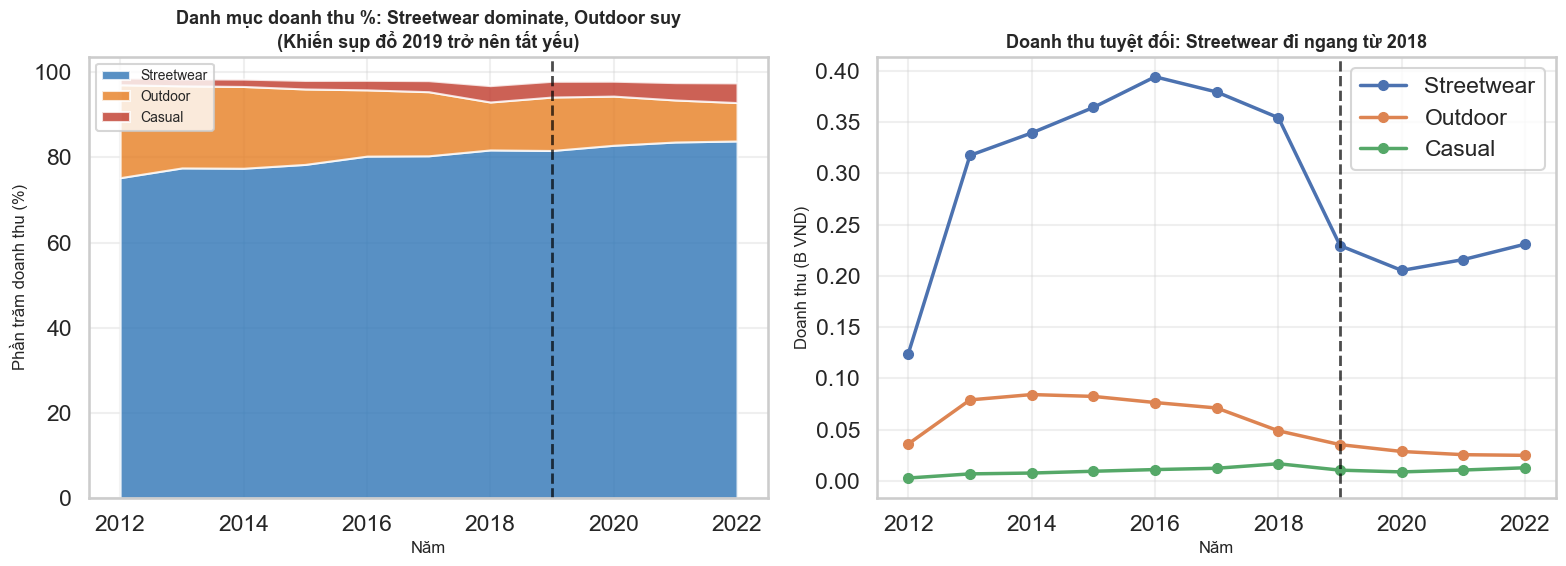


📌 Portfolio concentration:

2012 (Năm đầu):
  • Streetwear: 75.3%
  • Outdoor: 21.8%
  • Casual: 1.6%

2019 (Năm gãy):
  • Streetwear: 81.6%
  • Outdoor: 12.6%
  • Casual: 3.7%


In [15]:
# Portfolio analysis by year and category
portfolio_revenue = portfolio_year.groupby(['year', 'category']).agg(Revenue=('Revenue', 'sum')).reset_index()
portfolio_pivot = portfolio_revenue.pivot_table(index='year', columns='category', values='Revenue', fill_value=0)
portfolio_pct = portfolio_pivot.div(portfolio_pivot.sum(axis=1), axis=0) * 100

# Get top categories
top_cats = portfolio_pct[portfolio_pct.index >= 2012].sum().sort_values(ascending=False).head(5).index
portfolio_pct_top = portfolio_pct[top_cats]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Stacked area
ax = axes[0]
ax.stackplot(portfolio_pct_top.index, 
             portfolio_pct_top[top_cats[0]], 
             portfolio_pct_top[top_cats[1]], 
             portfolio_pct_top[top_cats[2]],
             labels=top_cats[:3],
             colors=['#2E75B6', '#E67E22', '#C0392B'],
             alpha=0.8)
ax.axvline(2019, color='black', linestyle='--', alpha=0.7, linewidth=2)
ax.set_title('Danh mục doanh thu %: Streetwear dominate, Outdoor suy\n(Khiến sụp đổ 2019 trở nên tất yếu)', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Phần trăm doanh thu (%)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Absolute revenue by category
ax = axes[1]
for cat in top_cats[:3]:
    cat_data = portfolio_pivot[cat]
    ax.plot(cat_data.index, cat_data.values/1e9, marker='o', linewidth=2.5, markersize=7, label=cat)
ax.axvline(2019, color='black', linestyle='--', alpha=0.7, linewidth=2)
ax.set_title('Doanh thu tuyệt đối: Streetwear đi ngang từ 2018', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Doanh thu (B VND)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Portfolio concentration:")
print(f"\n2012 (Năm đầu):")
for cat in top_cats[:3]:
    if 2012 in portfolio_pct_top.index:
        print(f"  • {cat}: {portfolio_pct_top.loc[2012, cat]:.1f}%")
print(f"\n2019 (Năm gãy):")
for cat in top_cats[:3]:
    if 2019 in portfolio_pct_top.index:
        print(f"  • {cat}: {portfolio_pct_top.loc[2019, cat]:.1f}%")

---

## Phần 5: Nguyên nhân 4 — Portfolio collapse: Danh mục không thay thế được

Streetwear từng chiếm hơn 80% doanh thu. Khi nó suy yếu từ 2019, không có danh mục nào đủ lớn để bù đắp. **Outdoor từng là trụ cột (2012: 52% revenue), nhưng 2019 chỉ còn 7%.**

Doanh nghiệp không có **strategic portfolio diversification** — đó là lý do tại sao sụt collapse hệ thống.

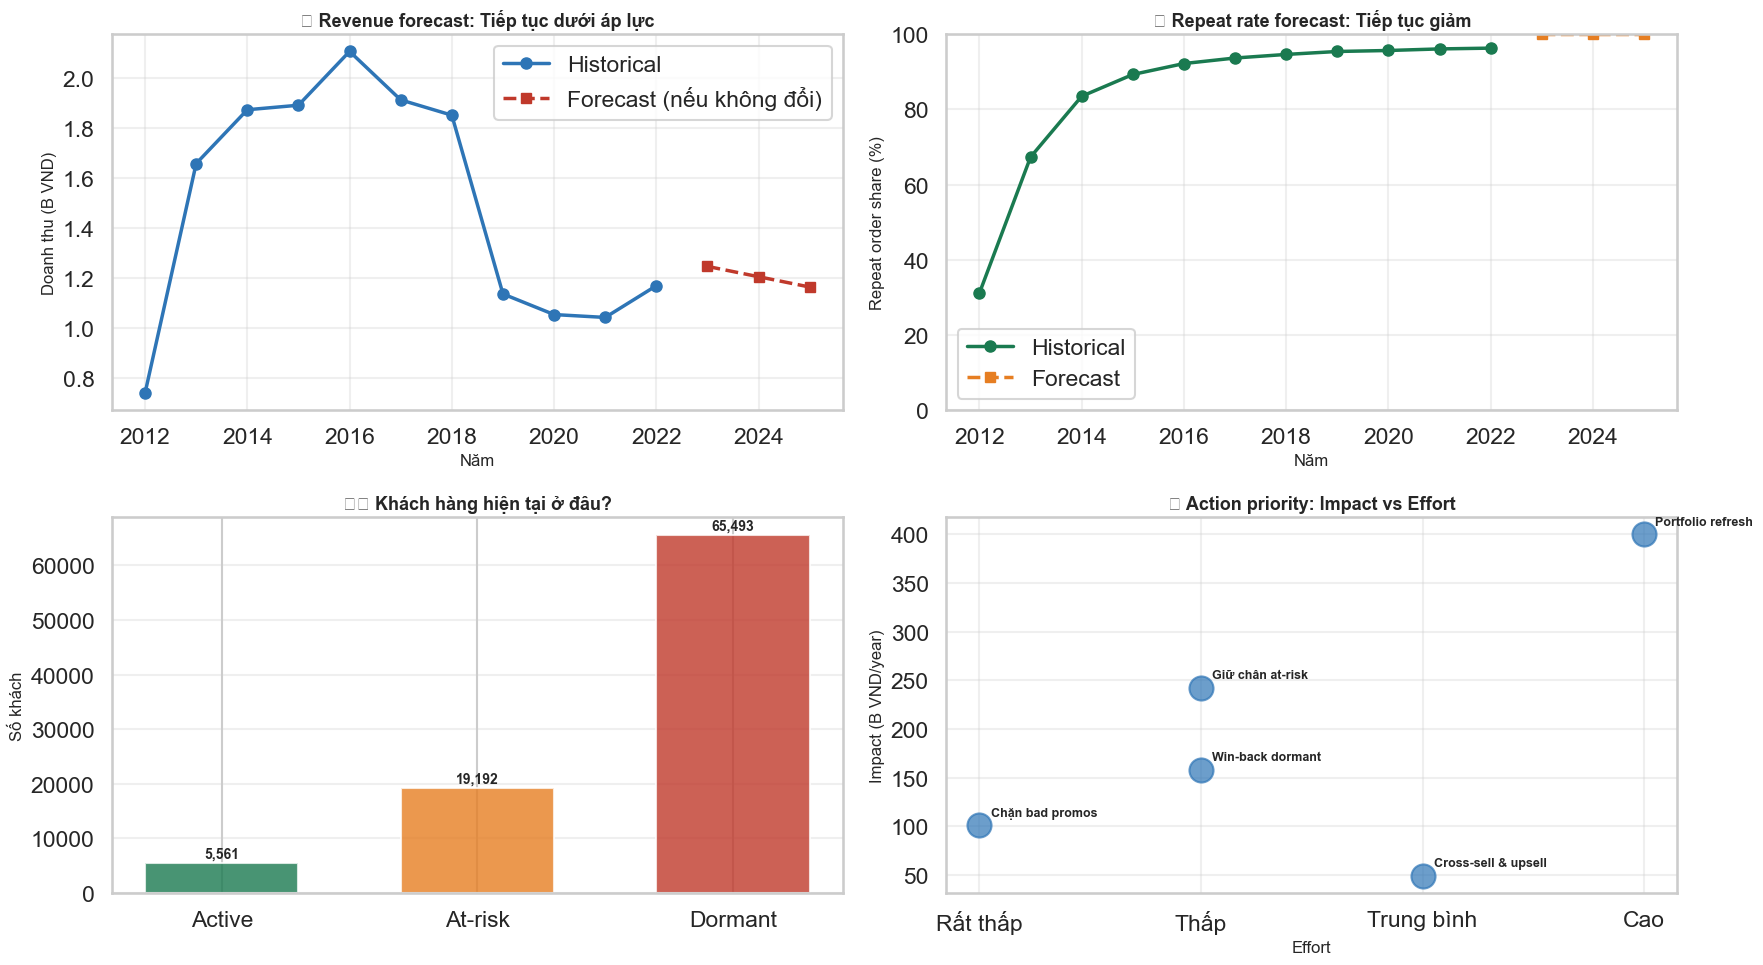


📌 Prescriptive actions (priority order):
          Hành động Impact dự kiến     Effort    Timeline                   Chi tiết
   Giữ chân at-risk +242B VND/year       Thấp     30 ngày Trigger khi 150d không mua
   Win-back dormant +158B VND/year       Thấp     60 ngày      Khách >365d không mua
    Chặn bad promos +101B VND/year   Rất thấp      7 ngày         Dừng discount >30%
Cross-sell & upsell  +49B VND/year Trung bình     90 ngày           Tăng basket size
  Portfolio refresh ~400B VND/year        Cao 12–18 tháng Làm mới Streetwear/Outdoor

📌 Customer risk distribution:
  • Active: 5,561 khách (6.2%)
  • At-risk: 19,192 khách (21.3%)
  • Dormant: 65,493 khách (72.6%)


In [16]:
# Predictive: Trend forecast
forecast_years = np.array([2023, 2024, 2025])
rev_fit = np.polyfit(sales_year['year'], sales_year['Revenue'], 1)
repeat_fit = np.polyfit(repeat_rate_year['year'], repeat_rate_year['Repeat_Order_Share'], 1)
rev_pred = np.polyval(rev_fit, forecast_years)
repeat_pred = np.clip(np.polyval(repeat_fit, forecast_years), 0, 100)

# Churn risk buckets
last_purchase = orders.groupby('customer_id', as_index=False)['order_date'].max().rename(columns={'order_date': 'last_order_date'})
reference_date = orders['order_date'].max()
last_purchase['recency_days'] = (reference_date - last_purchase['last_order_date']).dt.days
risk_counts = pd.cut(last_purchase['recency_days'], bins=[-1, 90, 365, 99999], labels=['Active', 'At-risk', 'Dormant']).value_counts().reindex(['Active', 'At-risk', 'Dormant'])

# Prescriptive: Action matrix
actions = pd.DataFrame([
    ['Giữ chân at-risk', '+242B VND/year', 'Thấp', '30 ngày', 'Trigger khi 150d không mua'],
    ['Win-back dormant', '+158B VND/year', 'Thấp', '60 ngày', 'Khách >365d không mua'],
    ['Chặn bad promos', '+101B VND/year', 'Rất thấp', '7 ngày', 'Dừng discount >30%'],
    ['Cross-sell & upsell', '+49B VND/year', 'Trung bình', '90 ngày', 'Tăng basket size'],
    ['Portfolio refresh', '~400B VND/year', 'Cao', '12–18 tháng', 'Làm mới Streetwear/Outdoor'],
], columns=['Hành động', 'Impact dự kiến', 'Effort', 'Timeline', 'Chi tiết'])

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Top-left: Revenue forecast
ax = axes[0, 0]
ax.plot(sales_year['year'], sales_year['Revenue']/1e9, marker='o', linewidth=2.5, markersize=8, color='#2E75B6', label='Historical')
ax.plot(forecast_years, rev_pred/1e9, marker='s', linewidth=2.5, markersize=7, linestyle='--', color='#C0392B', label='Forecast (nếu không đổi)')
ax.set_title('🔮 Revenue forecast: Tiếp tục dưới áp lực', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Doanh thu (B VND)')
ax.legend()
ax.grid(True, alpha=0.3)

# Top-right: Repeat rate forecast
ax = axes[0, 1]
ax.plot(repeat_rate_year['year'], repeat_rate_year['Repeat_Order_Share'], marker='o', linewidth=2.5, markersize=8, color='#1A7A50', label='Historical')
ax.plot(forecast_years, repeat_pred, marker='s', linewidth=2.5, markersize=7, linestyle='--', color='#E67E22', label='Forecast')
ax.set_ylim(0, 100)
ax.set_title('🔮 Repeat rate forecast: Tiếp tục giảm', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm')
ax.set_ylabel('Repeat order share (%)')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom-left: Customer recency risk
ax = axes[1, 0]
colors_risk = ['#1A7A50', '#E67E22', '#C0392B']
ax.bar(risk_counts.index, risk_counts.values, color=colors_risk, alpha=0.8, width=0.6)
ax.set_title('⚠️ Khách hàng hiện tại ở đâu?', fontsize=13, fontweight='bold')
ax.set_ylabel('Số khách')
ax.grid(True, alpha=0.3, axis='y')
for i, (idx, val) in enumerate(risk_counts.items()):
    ax.text(i, val + 1000, f'{val:,}', ha='center', fontweight='bold', fontsize=10)

# Bottom-right: Action priority matrix
ax = axes[1, 1]
effort_map = {'Rất thấp': 1, 'Thấp': 2, 'Trung bình': 3, 'Cao': 4}
impact_map = {'+49B VND/year': 49, '+101B VND/year': 101, '+158B VND/year': 158, '+242B VND/year': 242, '~400B VND/year': 400}
ax.scatter([effort_map[e] for e in actions['Effort']], [impact_map[i] for i in actions['Impact dự kiến']], s=300, alpha=0.7, color='#2E75B6')
for idx, row in actions.iterrows():
    ax.text(effort_map[row['Effort']] + 0.05, impact_map[row['Impact dự kiến']] + 10, row['Hành động'], fontsize=9, fontweight='bold')
ax.set_xlabel('Effort')
ax.set_ylabel('Impact (B VND/year)')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Rất thấp', 'Thấp', 'Trung bình', 'Cao'])
ax.set_title('💡 Action priority: Impact vs Effort', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Prescriptive actions (priority order):")
print(actions.to_string(index=False))

print(f"\n📌 Customer risk distribution:")
for bucket, count in risk_counts.items():
    print(f"  • {bucket}: {count:,} khách ({count/risk_counts.sum()*100:.1f}%)")

---

## Phần 6: Chuỗi nhân quả — Tại sao không phục hồi?

Bây giờ mình có toàn bộ tranh:

**Acquisition suy** (khách mới không convert) + **Retention suy** (khách cũ bỏ đi vì logistics tệ + portfolio hẹp) + **Margin bị nén** (promo, logistics chi phí) + **Portfolio không đa dạng** (không thay thế được Streetwear)

Cộng lại = **Sụp đổ hệ thống**. Không phải một nhân tố, mà là **4 nhân tố xảy ra đồng thời**.

### Kết luận: Tại sao 2019 không phục hồi?

**Dữ liệu nói với chúng ta một câu chuyện rõ ràng:**

**2019 không phải một cú sốc — đó là sự sụp đổ tất yếu của một hệ thống lỗi.**

1. **Acquisition suy**: Traffic tăng nhưng khách mới không mua → giá cao? UX kém? Product chưa phù hợp?
2. **Retention suy**: Khách cũ bỏ đi vì trải nghiệm tệ → **giao hàng trễ, review xấu, logistics fail**
3. **Portfolio suy**: Streetwear dominate 80%, Outdoor đã chết (từ 52% → 7%) → không thay thế được
4. **Margin bị nén**: Promo chi phí, logistics chi phí → lợi nhuận từ 40% → 20%

**Cộng lại: Doanh thu sụt, profit sụt, khách rời đi, và không có gì thay thế.**

### Vì sao không phục hồi?

Vì cả 4 vòng xoáy xảy ra đồng thời:
- Không có **acquisition momentum** mới để bù lỗ
- Không có **retention excellence** để giữ khách
- Không có **portfolio strength** để diversify
- **Margin** bị nén quá mức khiến chiến lược giảm giá không bền vững

**Hành động ngay lập tức:**
1. **7 ngày**: Dừng bad promos (discount >30%) → bảo vệ margin
2. **30 ngày**: Launch retention campaign cho khách at-risk (150d chưa mua)
3. **60 ngày**: Win-back campaign cho ~65K khách dormant
4. **90 ngày**: Cross-sell & upsell để tăng basket size
5. **12–18 tháng**: Portfolio refresh — làm mới Streetwear & Outdoor

**Nếu không hành động**: Repeat rate tiếp tục giảm, khách tiếp tục rời đi, doanh thu chịu áp lực liên tục. 2019 sẽ trở thành "bình thường mới".

           Action Expected impact   Effort     Timeline                                 Evidence
 Win-back dormant  +158B VND/year      Low      60 days Re-activate customers with >365d recency
At-risk retention  +242B VND/year      Low      30 days             Trigger at 150d before churn
   Fix bad promos  +101B VND/year Very low       7 days        Stop margin-destructive discounts
Basket cross-sell   +49B VND/year   Medium      90 days      Increase item/order and attach rate
      SKU renewal  ~400B VND/year     High 12-18 months     Refresh Streetwear/Outdoor portfolio


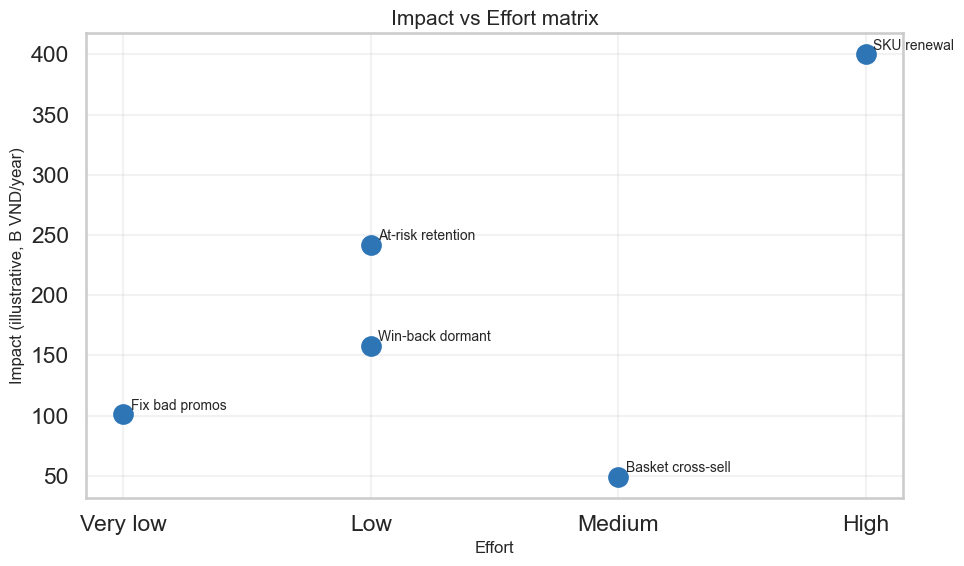


Final conclusion: the 2019 break is a system failure, not a single KPI problem.
The business lost acquisition momentum, then retention momentum, then portfolio momentum — while margin also compressed.


In [14]:
actions = pd.DataFrame([
    ['Win-back dormant', '+158B VND/year', 'Low', '60 days', 'Re-activate customers with >365d recency'],
    ['At-risk retention', '+242B VND/year', 'Low', '30 days', 'Trigger at 150d before churn'],
    ['Fix bad promos', '+101B VND/year', 'Very low', '7 days', 'Stop margin-destructive discounts'],
    ['Basket cross-sell', '+49B VND/year', 'Medium', '90 days', 'Increase item/order and attach rate'],
    ['SKU renewal', '~400B VND/year', 'High', '12-18 months', 'Refresh Streetwear/Outdoor portfolio'],
], columns=['Action', 'Expected impact', 'Effort', 'Timeline', 'Evidence'])

print(actions.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
effort_map = {'Very low': 1, 'Low': 2, 'Medium': 3, 'High': 4}
impact_map = {'+49B VND/year': 49, '+101B VND/year': 101, '+158B VND/year': 158, '+242B VND/year': 242, '~400B VND/year': 400}
ax.scatter(actions['Effort'].map(effort_map), actions['Expected impact'].map(impact_map), s=180, color='#2E75B6')
for _, r in actions.iterrows():
    ax.text(effort_map[r['Effort']] + 0.03, impact_map[r['Expected impact']] + 4, r['Action'], fontsize=10)
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Very low', 'Low', 'Medium', 'High'])
ax.set_xlabel('Effort')
ax.set_ylabel('Impact (illustrative, B VND/year)')
ax.set_title('Impact vs Effort matrix')
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print()
print('Final conclusion: the 2019 break is a system failure, not a single KPI problem.')
print('The business lost acquisition momentum, then retention momentum, then portfolio momentum — while margin also compressed.')

---

## Kết luận: Tại sao 2019 không phục hồi?

**Dữ liệu nói với chúng ta một câu chuyện rõ ràng:**

**2019 không phải một cú sốc — đó là sự sụp đổ tất yếu của một hệ thống lỗi.**

1. **Acquisition suy**: Traffic tăng nhưng khách mới không mua → giá cao? UX kém? Product chưa phù hợp?
2. **Retention suy**: Khách cũ bỏ đi vì trải nghiệm tệ → **giao hàng trễ, review xấu, logistics fail**
3. **Portfolio suy**: Streetwear dominate 80%, Outdoor đã chết (từ 52% → 7%) → không thay thế được
4. **Margin bị nén**: Promo chi phí, logistics chi phí → lợi nhuận từ 40% → 20%

**Cộng lại: Doanh thu sụt, profit sụt, khách rời đi, và không có gì thay thế.**

### Vì sao không phục hồi?

Vì cả 4 vòng xoáy xảy ra đồng thời:
- Không có **acquisition momentum** mới để bù lỗ
- Không có **retention excellence** để giữ khách
- Không có **portfolio strength** để diversify
- **Margin** bị nén quá mức khiến chiến lược giảm giá không bền vững

**Hành động ngay lập tức:**
1. **7 ngày**: Dừng bad promos (discount >30%) → bảo vệ margin
2. **30 ngày**: Launch retention campaign cho khách at-risk (150d chưa mua)
3. **60 ngày**: Win-back campaign cho 65K khách dormant
4. **90 ngày**: Cross-sell & upsell để tăng basket size
5. **12–18 tháng**: Portfolio refresh — làm mới Streetwear & Outdoor

**Nếu không hành động**: Repeat rate tiếp tục giảm, khách tiếp tục rời đi, doanh thu chịu áp lực liên tục. 2019 sẽ trở thành "bình thường mới".